<a href="https://colab.research.google.com/github/claudiorafaels/nondeterminism_llm_inference/blob/main/labs_2026_04_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Célula 1
!pip install vllm sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.7/627.7 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# Puxa o token secreto que você salvou com o nome "HF_TOKEN"
meu_token = userdata.get('HF_TOKEN')

# Faz o login silenciosamente, sem pedir para você digitar nada
login(token=meu_token)

print("Autenticado com sucesso via Secrets!")

Autenticado com sucesso via Secrets!


In [ ]:
# Célula 3: Motor 7B Blindado (Forçando variáveis no Sistema Operacional)
%env VLLM_USE_V1=0
%env VLLM_WORKER_MULTIPROC_METHOD=spawn

from vllm import LLM, SamplingParams

print("Iniciando Qwen 7B na GPU A100 (BFloat16 + Deep Layers)...")

try:
    llm = LLM(
        model="Qwen/Qwen2.5-7B-Instruct",
        dtype="bfloat16",
        max_model_len=1024,          # Reduzido preventivamente para evitar estouro de KV Cache
        gpu_memory_utilization=0.8,  # Margem segura para o S.O.
        enforce_eager=False,         # Permite o CUDA Graphs (necessário para o erro)
        distributed_executor_backend="uni"
    )
    print("\n✅ Motor de 7B carregado! VRAM alocada com sucesso.")
except Exception as e:
    print(f"\n❌ Falha: {e}")

env: VLLM_USE_V1=0
env: VLLM_WORKER_MULTIPROC_METHOD=spawn
Iniciando Qwen 7B na GPU A100 (BFloat16 + Deep Layers)...
INFO 04-16 00:30:44 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 1024, 'distributed_executor_backend': 'uni', 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-7B-Instruct'}
WARNING 04-16 00:30:44 [envs.py:1744] Unknown vLLM environment variable detected: VLLM_USE_V1


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

INFO 04-16 00:31:10 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-16 00:31:10 [model.py:1678] Using max model len 1024
INFO 04-16 00:31:10 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-16 00:31:10 [vllm.py:790] Asynchronous scheduling is enabled.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


✅ Motor de 7B carregado! VRAM alocada com sucesso.


In [ ]:
# Célula 4/5 V4: Simulador de Sensibilidade por Consistência Interna (Unique Count)
import random
import numpy as np
import pandas as pd
from collections import Counter
from vllm import SamplingParams

sampling_params = SamplingParams(temperature=0.0, top_p=1.0, max_tokens=10, seed=42)
prompt_bruto = "Defina o conceito de Transformação Digital em exatamente 6 palavras, nem mais, nem menos."
prompt_formatado = llm.get_tokenizer().apply_chat_template([{"role": "user", "content": prompt_bruto}], tokenize=False, add_generation_prompt=True)

grupos_carga = [int(x) for x in np.linspace(1, 250, 30)]
iteracoes_por_grupo = 20
resultados_estatisticos = []

print(f"Iniciando Teste Escalonado por Consistência Interna ({len(grupos_carga)} grupos, 600 inferências totais)...\n")

for carga in grupos_carga:
    respostas_deste_grupo = []

    print(f"🚀 Testando patamar de {carga} requisições simultâneas...")

    for i in range(iteracoes_por_grupo):
        # Apenas simulamos o ruído se a carga for maior que 1
        if carga > 1:
            prompts_ruido = [f"Explain tech in {random.randint(10, 500)} words."] * (carga - 1)
            lote = [prompt_formatado] + [
                llm.get_tokenizer().apply_chat_template([{"role":"user","content":p}], tokenize=False, add_generation_prompt=True)
                for p in prompts_ruido
            ]
        else:
            lote = [prompt_formatado]

        out = llm.generate(lote, sampling_params, use_tqdm=False)
        # O resultado do nosso prompt alvo é sempre o índice 0 do lote
        texto_gerado = out[0].outputs[0].text.strip()
        respostas_deste_grupo.append(texto_gerado)

    # --- A MÁGICA DA NOVA MÉTRICA AQUI ---
    # Contamos as ocorrências de cada resposta gerada nestas 20 iterações
    contagem = Counter(respostas_deste_grupo)
    qtd_respostas_unicas = len(contagem)

    # A resposta dominante (a Moda) será considerada a "correta" para este patamar
    resposta_dominante = contagem.most_common(1)[0][0]
    ocorrencias_dominante = contagem.most_common(1)[0][1]

    # Qualquer coisa que não seja a resposta dominante é um erro de reprodutibilidade
    taxa_erro = ((iteracoes_por_grupo - ocorrencias_dominante) / iteracoes_por_grupo) * 100

    resultados_estatisticos.append({
        "Carga": carga,
        "Respostas_Unicas": qtd_respostas_unicas,
        "Frequencia_Erro_%": taxa_erro,
        "Resposta_Dominante": resposta_dominante,
        "Todas_Variacoes": list(contagem.keys())
    })

df_resultados = pd.DataFrame(resultados_estatisticos)
print("\n✅ Teste de Consistência Interna Concluído!")

Iniciando Teste Escalonado por Consistência Interna (30 grupos, 600 inferências totais)...

🚀 Testando patamar de 1 requisições simultâneas...
🚀 Testando patamar de 9 requisições simultâneas...
🚀 Testando patamar de 18 requisições simultâneas...
🚀 Testando patamar de 26 requisições simultâneas...
🚀 Testando patamar de 35 requisições simultâneas...
🚀 Testando patamar de 43 requisições simultâneas...
🚀 Testando patamar de 52 requisições simultâneas...
🚀 Testando patamar de 61 requisições simultâneas...
🚀 Testando patamar de 69 requisições simultâneas...
🚀 Testando patamar de 78 requisições simultâneas...
🚀 Testando patamar de 86 requisições simultâneas...
🚀 Testando patamar de 95 requisições simultâneas...
🚀 Testando patamar de 104 requisições simultâneas...
🚀 Testando patamar de 112 requisições simultâneas...
🚀 Testando patamar de 121 requisições simultâneas...
🚀 Testando patamar de 129 requisições simultâneas...
🚀 Testando patamar de 138 requisições simultâneas...
🚀 Testando patamar de

In [ ]:
# Célula 6 V4: Análise Semântica de Consistência Interna e Correlação
from sentence_transformers import SentenceTransformer, util

print("Carregando modelo de Embeddings (all-MiniLM-L6-v2)...")
modelo_emb = SentenceTransformer('all-MiniLM-L6-v2')

print("\n" + "="*70)
print("RELATÓRIO DE SENSIBILIDADE E DRIFT SEMÂNTICO (CONSISTÊNCIA INTERNA)")
print("="*70)

for res in resultados_estatisticos:
    carga = res['Carga']
    frequencia_erro = res['Frequencia_Erro_%']
    respostas_unicas = res['Respostas_Unicas']
    dominante = res['Resposta_Dominante']
    todas_variacoes = res['Todas_Variacoes']

    print(f"\nNível de Carga: {carga} req/simultâneas")
    print(f"Respostas Únicas: {respostas_unicas} | Frequência de Erro Interno: {frequencia_erro:.2f}%")

    # Se houver mais de 1 resposta única, o determinismo quebrou naquele patamar
    if respostas_unicas > 1:
        print(f"  [Moda/Dominante]: '{dominante}'")
        emb_dominante = modelo_emb.encode(dominante, convert_to_tensor=True)

        # Calcula o drift de todas as anomalias em relação à resposta dominante
        for var in todas_variacoes:
            if var != dominante:
                emb_var = modelo_emb.encode(var, convert_to_tensor=True)
                sim = util.cos_sim(emb_dominante, emb_var).item() * 100
                print(f"  [Anomalia]: '{var}'")
                print(f"  ↳ Similaridade: {sim:.2f}% | Drift Semântico: {100-sim:.2f}%")
    else:
        print("  -> Determinismo absoluto preservado (100% de consistência).")

# Cálculo do Coeficiente de Pearson (A prova de correlação Carga vs Falha)
correlacao = df_resultados['Carga'].corr(df_resultados['Frequencia_Erro_%'])

print("\n" + "-"*70)
print(f"COEFICIENTE DE CORRELAÇÃO (Pearson): {correlacao:.4f}")

if correlacao > 0.7:
    interpretacao = "Forte correlação positiva entre Carga e Não-Determinismo."
elif correlacao > 0.3:
    interpretacao = "Correlação moderada detectada (comum em sistemas complexos de hardware)."
else:
    interpretacao = "Correlação fraca. O ruído parece não escalar linearmente com a carga."

print(f"Interpretação: {interpretacao}")
print("-" * 70)

Carregando modelo de Embeddings (all-MiniLM-L6-v2)...

RELATÓRIO DE SENSIBILIDADE E DRIFT SEMÂNTICO (CONSISTÊNCIA INTERNA)

Nível de Carga: 1 req/simultâneas
Respostas Únicas: 1 | Frequência de Erro Interno: 0.00%
  -> Determinismo absoluto preservado (100% de consistência).

Nível de Carga: 9 req/simultâneas
Respostas Únicas: 1 | Frequência de Erro Interno: 0.00%
  -> Determinismo absoluto preservado (100% de consistência).

Nível de Carga: 18 req/simultâneas
Respostas Únicas: 1 | Frequência de Erro Interno: 0.00%
  -> Determinismo absoluto preservado (100% de consistência).

Nível de Carga: 26 req/simultâneas
Respostas Únicas: 1 | Frequência de Erro Interno: 0.00%
  -> Determinismo absoluto preservado (100% de consistência).

Nível de Carga: 35 req/simultâneas
Respostas Únicas: 2 | Frequência de Erro Interno: 45.00%
  [Moda/Dominante]: 'Inovação digital para negócios transformados'
  [Anomalia]: 'Inovação digital para processos corporativos.'
  ↳ Similaridade: 76.15% | Drift Semântic

Gerando gráfico de alta resolução e exportando arquivos...


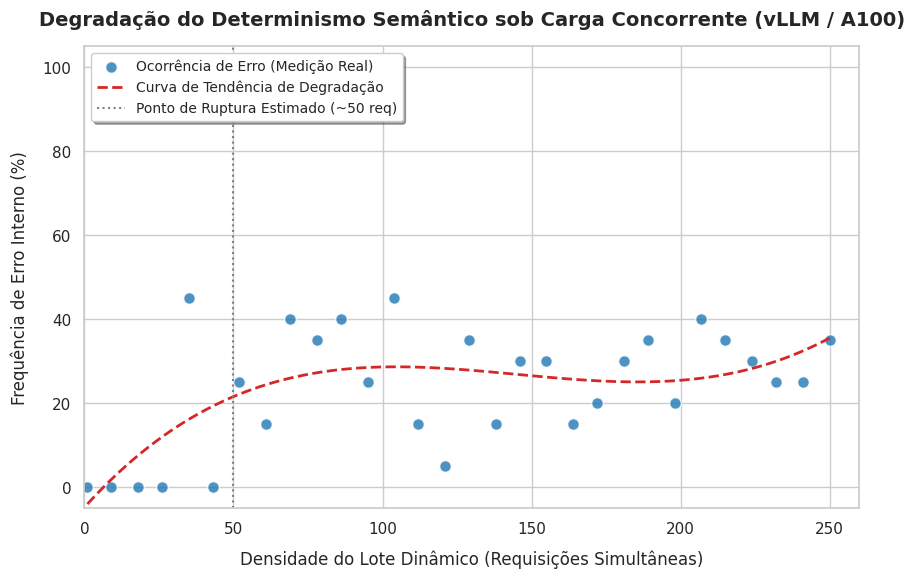


SUCESSO! Arquivos gerados:
1. Grafico_TCC_Degradacao_Alta_Resolucao.png (Pronto para o Word)
2. Resultados_MonteCarlo_TCC.xlsx (Pronto para o Excel)
-> Verifique o menu de arquivos (ícone de pasta) na lateral esquerda do Colab para fazer o download.


In [ ]:
# Célula 7: Visualização Acadêmica e Exportação de Dados (Padrão Artigo)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Gerando gráfico de alta resolução e exportando arquivos...")

# 1. Configuração de estilo limpo para trabalhos acadêmicos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Extraindo os eixos do nosso dataframe
x = df_resultados['Carga']
y = df_resultados['Frequencia_Erro_%']

# 2. Plotagem dos pontos reais (Scatter Plot)
plt.scatter(x, y, color='#1f77b4', alpha=0.8, edgecolors='w', s=70, label='Ocorrência de Erro (Medição Real)')

# 3. Cálculo da Linha de Tendência (Regressão Polinomial para capturar a curva S)
z = np.polyfit(x, y, 3) # Polinômio de grau 3 para suavizar a curva de degradação
p = np.poly1d(z)

# Gerando a linha suave
x_linha = np.linspace(min(x), max(x), 100)
plt.plot(x_linha, p(x_linha), color='#d62728', linestyle='--', linewidth=2, label='Curva de Tendência de Degradação')

# 4. Marcando o Ponto de Ruptura (Tipping Point ~ 50 requisições)
plt.axvline(x=50, color='gray', linestyle=':', linewidth=1.5, label='Ponto de Ruptura Estimado (~50 req)')

# 5. Formatação ABNT (Títulos e Rótulos)
plt.title('Degradação do Determinismo Semântico sob Carga Concorrente (vLLM / A100)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Densidade do Lote Dinâmico (Requisições Simultâneas)', fontsize=12, labelpad=10)
plt.ylabel('Frequência de Erro Interno (%)', fontsize=12, labelpad=10)

# Travando os eixos para fazer sentido percentual
plt.ylim(-5, 105)
plt.xlim(0, 260)

# Posicionando a legenda
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

# 6. Salvando a imagem em 300 DPI (Altíssima Qualidade para o Word)
plt.savefig('Grafico_TCC_Degradacao_Alta_Resolucao.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Exportação dos Dados Brutos para Excel
df_resultados.to_excel('Resultados_MonteCarlo_TCC.xlsx', index=False)

print("\n" + "="*70)
print("SUCESSO! Arquivos gerados:")
print("1. Grafico_TCC_Degradacao_Alta_Resolucao.png (Pronto para o Word)")
print("2. Resultados_MonteCarlo_TCC.xlsx (Pronto para o Excel)")
print("-> Verifique o menu de arquivos (ícone de pasta) na lateral esquerda do Colab para fazer o download.")
print("="*70)